In [1]:
#| include: false
!pip install quarto-cli

In [2]:
#| include: false
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
title: "Early Initiation of Breastfeeding: A Global Analysis"

author: "Aditi Vadagave"

date: today

format:

  html:
    embed-resources: true
    code-fold: true
    theme: cosmo
    toc: true
---

No matter where a newborn takes his or her first breath, the desire to give that baby the best start in life is universal. The first hours and days after birth are one of the riskiest period of a child's life, but getting an early start to breastfeeding offers a powerful line of defense.

Despite its well-documented benefits, breastfeeding rates vary **widely**
across countries and regions, shaped by a complex mix of cultural practices,
healthcare systems, policy environments, and socioeconomic factors. No single
indicator fully explains why some countries succeed and others fall behind.

This report explores global patterns in early breastfeeding initiation using
data from **UNICEF**, examining how rates differ across regions, how they have
changed over time, and what other development indicators may or may not
explain those differences. Key questions explored include:

- How do breastfeeding rates vary across countries and regions?
- Has global progress been consistent over time?
- Do healthcare access, GDP, or life expectancy explain differences in rates?

In [3]:
#| include: false
!pip install plotnine geopandas geodatasets polars --quiet

In [4]:
#| include: false
import polars as pl
import numpy as np
import geopandas as gpd
import warnings
import pyogrio, os
warnings.filterwarnings("ignore")

from plotnine import (
    ggplot, aes,
    geom_map, geom_point, geom_col, geom_line, geom_smooth,
    geom_hline, geom_vline, geom_text, geom_tile, geom_rect,
    scale_fill_gradient, scale_fill_gradient2, scale_color_identity, scale_fill_manual, scale_fill_continuous,
    scale_color_manual, scale_color_gradient,
    scale_x_continuous, scale_y_continuous, scale_x_discrete,
    coord_cartesian, coord_flip,
    facet_wrap,
    facet_null,
    annotate,
    labs, theme, theme_minimal, theme_void, theme_bw,
    element_text, element_blank, element_line, element_rect,
    ggsave
)
from IPython.display import Image, display

# ── World shapefile ──
WORLD_SHP = os.path.join(os.path.dirname(pyogrio.__file__),
                         "tests", "fixtures",
                         "naturalearth_lowres",
                         "naturalearth_lowres.shp")

def show(filename):
    display(Image(filename))

# ── Shared style constants ──
FONT_TITLE    = 14
FONT_SUBTITLE = 10
FONT_AXIS     = 10
FONT_ANNOT    = 8
FONT_TICK     = 8
C_RED         = "#c62828"
C_GREEN       = "#2e7d32"
C_BLUE        = "#0d47a1"
C_ORANGE      = "#e65100"
C_GREY        = "#666666"

CONT_COLORS = {
    "Africa":        "#e65100",
    "Asia":          "#1565c0",
    "Europe":        "#6a1b9a",
    "North America": "#f9a825",
    "South America": "#ad1457",
    "Oceania":       "#2e7d32",
    "Other":         "#888888",
}

BASE_THEME = (
    theme_minimal()
    + theme(
        plot_title       = element_text(size=FONT_TITLE, weight="bold"),
        plot_subtitle    = element_text(size=FONT_SUBTITLE, color=C_GREY),
        axis_title       = element_text(size=FONT_AXIS),
        axis_text        = element_text(size=FONT_TICK),
        panel_grid_minor = element_blank(),
        panel_grid_major = element_line(color="#eeeeee"),
        plot_caption     = element_text(size=7, color="#aaaaaa"),
        legend_text      = element_text(size=FONT_TICK),
        legend_title     = element_text(size=FONT_TICK, weight="bold"),
    )
)

In [5]:
#| include: false

# ── Load raw data ──
ind1_pl = pl.read_csv("/content/drive/MyDrive/UNICEF/data/unicef_indicator_1.csv").with_columns(
    pl.col("time_period").cast(pl.Float64, strict=False)
)
ind2_pl = pl.read_csv("/content/drive/MyDrive/UNICEF/data/unicef_indicator_2.csv", schema_overrides={"time_period": pl.Utf8}).with_columns(
    pl.col("time_period").cast(pl.Float64, strict=False)
)
meta_pl = pl.read_csv("/content/drive/MyDrive/UNICEF/data/unicef_metadata.csv").with_columns(
    pl.col("year").cast(pl.Float64, strict=False)
)

# ── Transformations ──
ind2_total = ind2_pl.filter(pl.col("sex") == "Total")

ind2_latest = (
    ind2_total
    .group_by(["country", "alpha_3_code"])
    .agg(
        pl.col("obs_value").sort_by("time_period").last().alias("breastfeed_pct"),
        pl.col("time_period").max().alias("year2")
    )
)

ind1_latest = (
    ind1_pl
    .group_by(["country", "alpha_3_code"])
    .agg(
        pl.col("obs_value").sort_by("time_period").last().alias("skilled_birth_pct"),
        pl.col("time_period").max().alias("year1")
    )
)

# .drop_nulls() is applied before .last() on each column to replicate pandas groupby().last()
# behaviour, which skips nulls and returns the most recent non-null value per country

meta_latest = (
    meta_pl
    .group_by("country")
    .agg([
        pl.col("year").max(),
        pl.col("Life expectancy at birth, total (years)").sort_by("year").drop_nulls().last(),
        pl.col("GDP per capita (constant 2015 US$)").sort_by("year").drop_nulls().last(),
        pl.col("Birth rate, crude (per 1,000 people)").sort_by("year").drop_nulls().last(),
    ])
)

merged = (
    ind1_latest
    .join(ind2_latest, on=["country", "alpha_3_code"], how="inner")
    .join(meta_latest.select(["country",
                               "GDP per capita (constant 2015 US$)",
                               "Life expectancy at birth, total (years)",
                               "Birth rate, crude (per 1,000 people)"]),
          on="country", how="left")
    .rename({
        "GDP per capita (constant 2015 US$)":      "gdp_per_capita",
        "Life expectancy at birth, total (years)": "life_expectancy",
        "Birth rate, crude (per 1,000 people)":    "birth_rate",
    })
)

# ── World shapefile ──
world = gpd.read_file(WORLD_SHP)
world = world.rename(columns={"iso_a3": "alpha_3_code", "continent": "CONTINENT"})

# ── Convert to pandas for plotting ──
# plotnine & geopandas require pandas-compatible input
ind2_latest = ind2_latest.to_pandas()
ind2_total  = ind2_total.to_pandas()
merged      = merged.to_pandas()
global_avg  = ind2_latest["breastfeed_pct"].mean()

In [6]:
#| label: eda-summary
#| include: false

# --- Data shape & quality ---
print("--- ind2 (Breastfeeding Indicator) ---")
print(f"Shape: {ind2_pl.shape}")
print(f"Countries: {ind2_pl['country'].n_unique()}")
print(f"Years: {int(ind2_pl['time_period'].min())} – {int(ind2_pl['time_period'].max())}")
print(f"Null obs_value: {ind2_pl['obs_value'].null_count()}")

print("\n--- metadata ---")
print(f"Shape: {meta_pl.shape}")
print(f"Countries: {meta_pl['country'].n_unique()}")
print(f"Null GDP: {meta_pl['GDP per capita (constant 2015 US$)'].null_count()}")
print(f"Null Life Expectancy: {meta_pl['Life expectancy at birth, total (years)'].null_count()}")

print("\n--- Breastfeeding Rate Summary (latest per country) ---")
print(ind2_pl
    .filter(pl.col("sex") == "Total")
    .select("obs_value")
    .describe()
)

--- ind2 (Breastfeeding Indicator) ---
Shape: (1273, 14)
Countries: 135
Years: 1991 – 2024
Null obs_value: 0

--- metadata ---
Shape: (13715, 15)
Countries: 211
Null GDP: 2494
Null Life Expectancy: 245

--- Breastfeeding Rate Summary (latest per country) ---
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ obs_value │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 579.0     │
│ null_count ┆ 0.0       │
│ mean       ┆ 49.11848  │
│ std        ┆ 17.927983 │
│ min        ┆ 6.0       │
│ 25%        ┆ 35.8      │
│ 50%        ┆ 49.2      │
│ 75%        ┆ 60.9      │
│ max        ┆ 93.7      │
└────────────┴───────────┘


## Global Overview

Breastfeeding rates vary widely across regions, with some countries achieving
high coverage while others remain significantly behind. The map below shows the
latest available data for each country, highlighting the stark disparities
between nations.

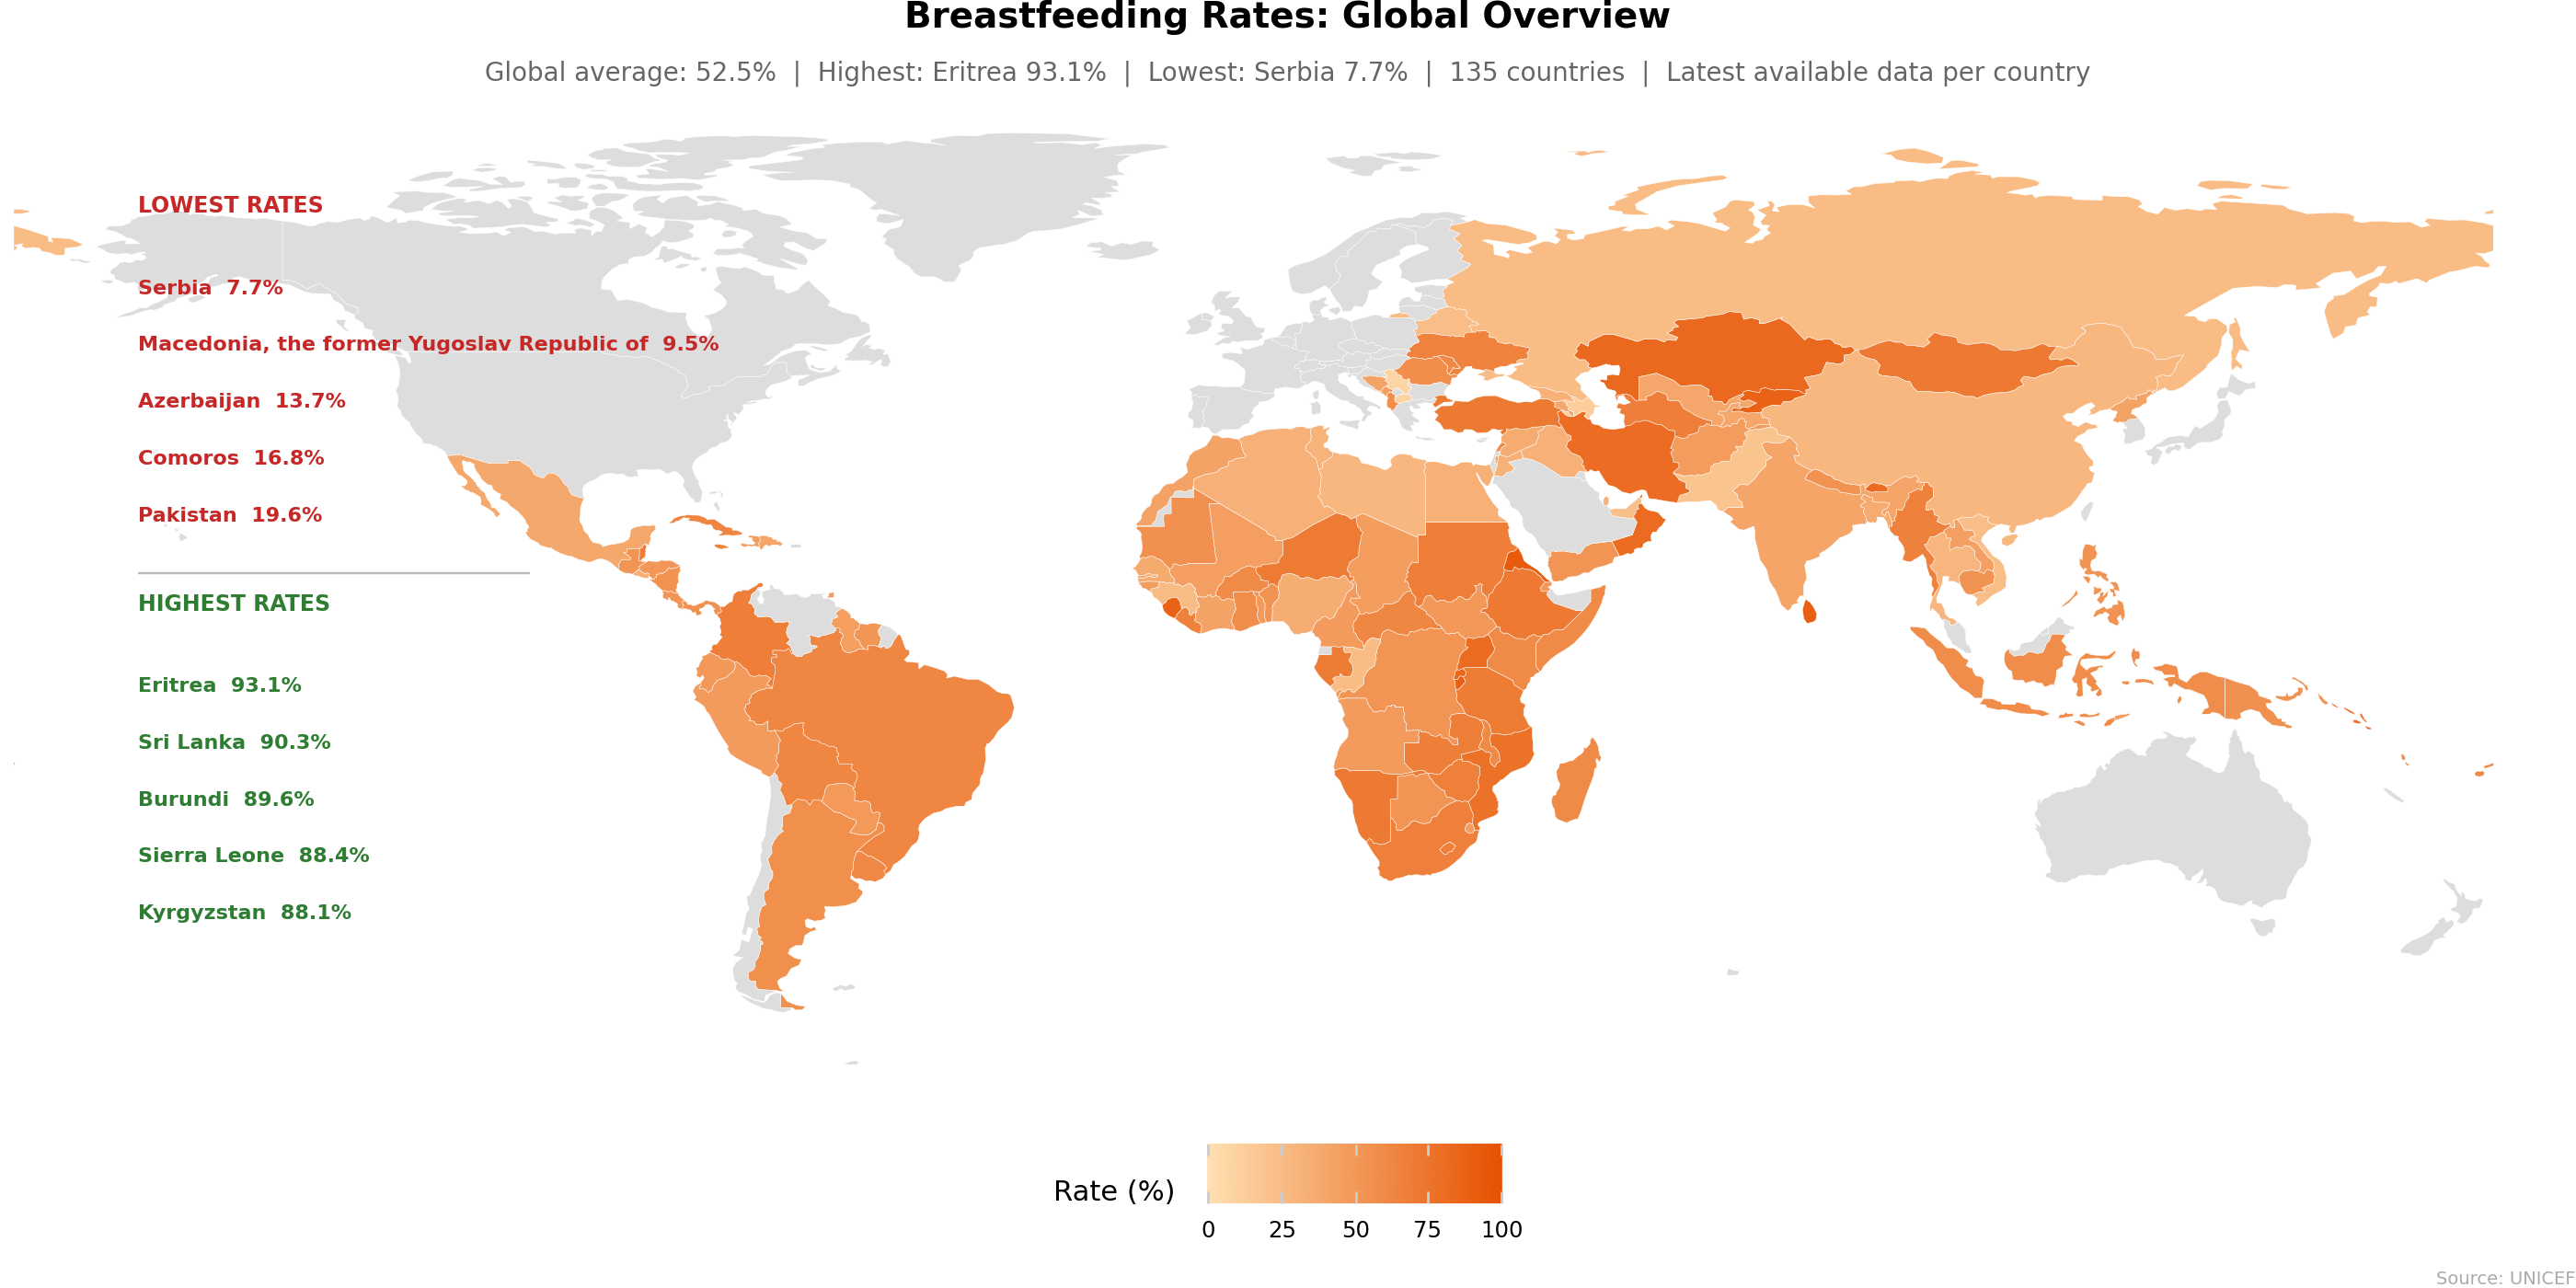

In [7]:
#| fig-cap: "Early Initiation of Breastfeeding Rates by Country"
#| fig-width: 14
#| fig-height: 7

map_bf = world.merge(
    ind2_latest[["alpha_3_code", "breastfeed_pct"]],
    on="alpha_3_code", how="left"
)

highest_bf = ind2_latest.loc[ind2_latest["breastfeed_pct"].idxmax()]
lowest_bf  = ind2_latest.loc[ind2_latest["breastfeed_pct"].idxmin()]
n_bf       = ind2_latest["country"].nunique()
top5_bf    = ind2_latest.nlargest(5,  "breastfeed_pct")[["country","breastfeed_pct"]].reset_index(drop=True)
bottom5_bf = ind2_latest.nsmallest(5, "breastfeed_pct")[["country","breastfeed_pct"]].reset_index(drop=True)

LOW_START  = 68
HIGH_START = LOW_START - 5 * 9 - 18
ROW        = 9

low_annots  = [annotate("text", x=-162, y=LOW_START  - (i+1) * ROW,
                         label=f"{row['country']}  {row['breastfeed_pct']:.1f}%",
                         color=C_RED, size=FONT_ANNOT, ha="left", fontweight="bold")
               for i, row in bottom5_bf.sort_values("breastfeed_pct").reset_index(drop=True).iterrows()]

high_annots = [annotate("text", x=-162, y=HIGH_START - (i+1) * ROW,
                         label=f"{row['country']}  {row['breastfeed_pct']:.1f}%",
                         color=C_GREEN, size=FONT_ANNOT, ha="left", fontweight="bold")
               for i, row in top5_bf.sort_values("breastfeed_pct", ascending=False).reset_index(drop=True).iterrows()]

p1 = (
    ggplot(map_bf)
    + geom_map(aes(fill="breastfeed_pct"), color="white", size=0.1)
    + scale_fill_gradient(
        low="#ffe0b2", high="#e65100",
        na_value="#dddddd",
        name="Rate (%)",
        limits=[0, 100],
    )
    + coord_cartesian(xlim=(-165, 175), ylim=(-57, 80))
    + annotate("text", x=-162, y=LOW_START + 4, label="LOWEST RATES", color=C_RED, size=FONT_ANNOT + 0.5, ha="left", fontweight="bold")
    + annotate("text", x=-162, y=HIGH_START + 4, label="HIGHEST RATES", color=C_GREEN, size=FONT_ANNOT + 0.5, ha="left", fontweight="bold")
    + annotate("segment", x=-162, xend=-105, y=HIGH_START + 9, yend=HIGH_START + 9, color="#bbbbbb", size=0.5)
    + low_annots[0]  + low_annots[1]  + low_annots[2]
    + low_annots[3]  + low_annots[4]
    + high_annots[0] + high_annots[1] + high_annots[2]
    + high_annots[3] + high_annots[4]
    + labs(
        title="Breastfeeding Rates: Global Overview",
        subtitle=(
            f"Global average: {global_avg:.1f}%  |  "
            f"Highest: {highest_bf['country']} {highest_bf['breastfeed_pct']:.1f}%  |  "
            f"Lowest: {lowest_bf['country']} {lowest_bf['breastfeed_pct']:.1f}%  |  "
            f"{n_bf} countries  |  Latest available data per country"
        ),
        caption="Source: UNICEF",
    )
    + theme_void()
    + theme(
        plot_title      = element_text(size=FONT_TITLE,    weight="bold", ha="center"),
        plot_subtitle   = element_text(size=FONT_SUBTITLE, color=C_GREY,  ha="center"),
        plot_caption    = element_text(size=7, color="#aaaaaa"),
        legend_position = "bottom",
        figure_size     = (14, 7),
    )
)
p1

## Global Trend in Early Breastfeeding (1991–2024)

Globally, early breastfeeding rates have shown **gradual improvement** over
time. However, progress is uneven and not consistent across all countries.
The dashed line shows the overall linear trend, while the coloured bands
indicate performance thresholds set by global health benchmarks.

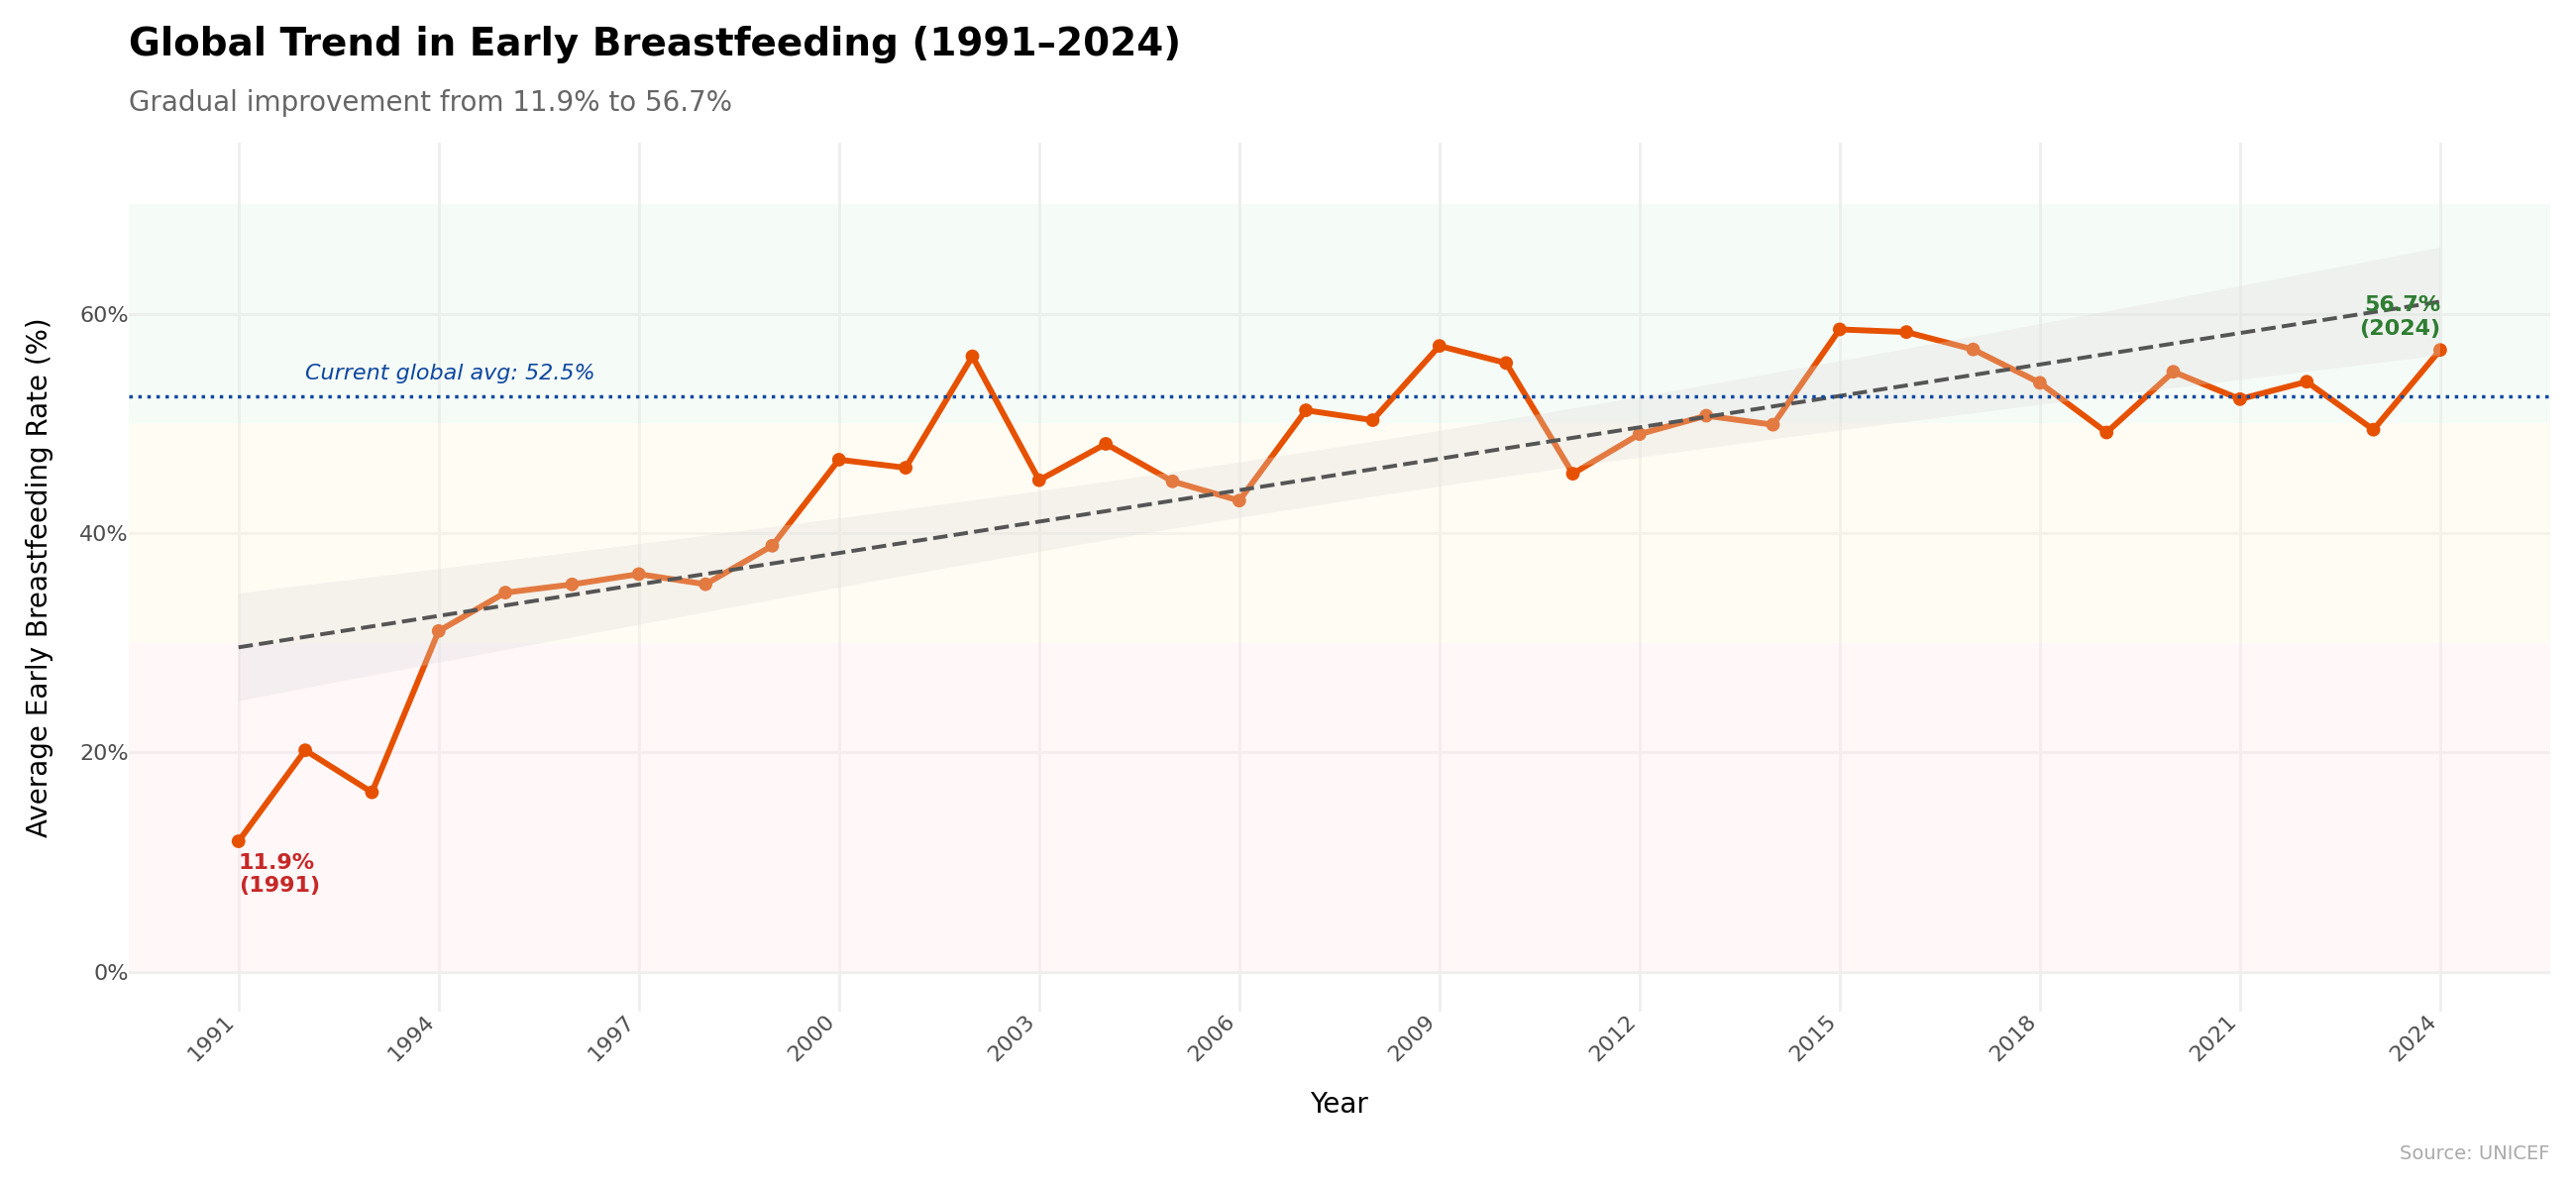

In [8]:
#| fig-cap: "Global Trend in Early Initiation of Breastfeeding (1991–2024)"
#| fig-width: 13
#| fig-height: 6

yoy_bf = (
    ind2_total.groupby("time_period", as_index=False)["obs_value"]
    .mean()
    .rename(columns={"obs_value": "avg_rate", "time_period": "year"})
    .dropna()
    .query("year >= 1991")
    .sort_values("year")  # ensures iloc[0] and iloc[-1] are correct
)

first_bf = yoy_bf.iloc[0]
last_bf  = yoy_bf.iloc[-1]

bands = pl.DataFrame({
    "ymin":  [0,  30, 50],
    "ymax":  [30, 50, 70],
    "label": ["Poor (<30%)", "Moderate (30–50%)", "Good (50–70%)"],
    "fill":  ["#ffebee", "#fff8e1", "#e8f5e9"],
})

p3 = (
    ggplot(yoy_bf, aes(x="year", y="avg_rate"))
    + geom_rect(
        data=bands,
        mapping=aes(xmin=-np.inf, xmax=np.inf, ymin="ymin", ymax="ymax", fill="fill"),
        alpha=0.4, inherit_aes=False, show_legend=False
    )
    + scale_fill_manual(values={v: v for v in bands["fill"]})
    + geom_line(color=C_ORANGE, size=1.2)
    + geom_point(color=C_ORANGE, size=1.8)
    + geom_smooth(method="lm", color="#555555", linetype="dashed",
                  fill="#dddddd", alpha=0.3, size=0.8)
    + geom_hline(yintercept=global_avg, linetype="dotted",
                 color=C_BLUE, size=0.7)
    + annotate("text", x=1992, y=global_avg + 2,
               label=f"Current global avg: {global_avg:.1f}%",
               size=FONT_ANNOT, color=C_BLUE, fontstyle="italic", ha="left")
    + annotate("text", x=first_bf["year"], y=first_bf["avg_rate"] - 3,
               label=f"{first_bf['avg_rate']:.1f}%\n({int(first_bf['year'])})",
               size=FONT_ANNOT, color=C_RED, fontweight="bold", ha="left")
    + annotate("text", x=last_bf["year"], y=last_bf["avg_rate"] + 3,
               label=f"{last_bf['avg_rate']:.1f}%\n({int(last_bf['year'])})",
               size=FONT_ANNOT, color=C_GREEN, fontweight="bold", ha="right")
    + scale_x_continuous(breaks=list(range(1991, 2025, 3)))
    + scale_y_continuous(
        limits=[0, 72],
        labels=lambda l: [f"{int(v)}%" for v in l]
    )
    + labs(
        title="Global Trend in Early Breastfeeding (1991–2024)",
        subtitle=f"Gradual improvement from {first_bf['avg_rate']:.1f}% to {last_bf['avg_rate']:.1f}%",
        x="Year", y="Average Early Breastfeeding Rate (%)",
        caption="Source: UNICEF",
    )
    + BASE_THEME
    + theme(
        axis_text_x = element_text(angle=45, ha="right"),
        figure_size = (13, 6),
    )
)
p3

## Leading Progress, and Falling Behind

While global breastfeeding rates have improved over time, progress has been
**uneven**. Some countries have made remarkable gains while others have
fallen behind. The chart below shows the top 10 improvers and top 10
decliners based on the change between their earliest (≤2005) and latest
(≥2015) available survey data.

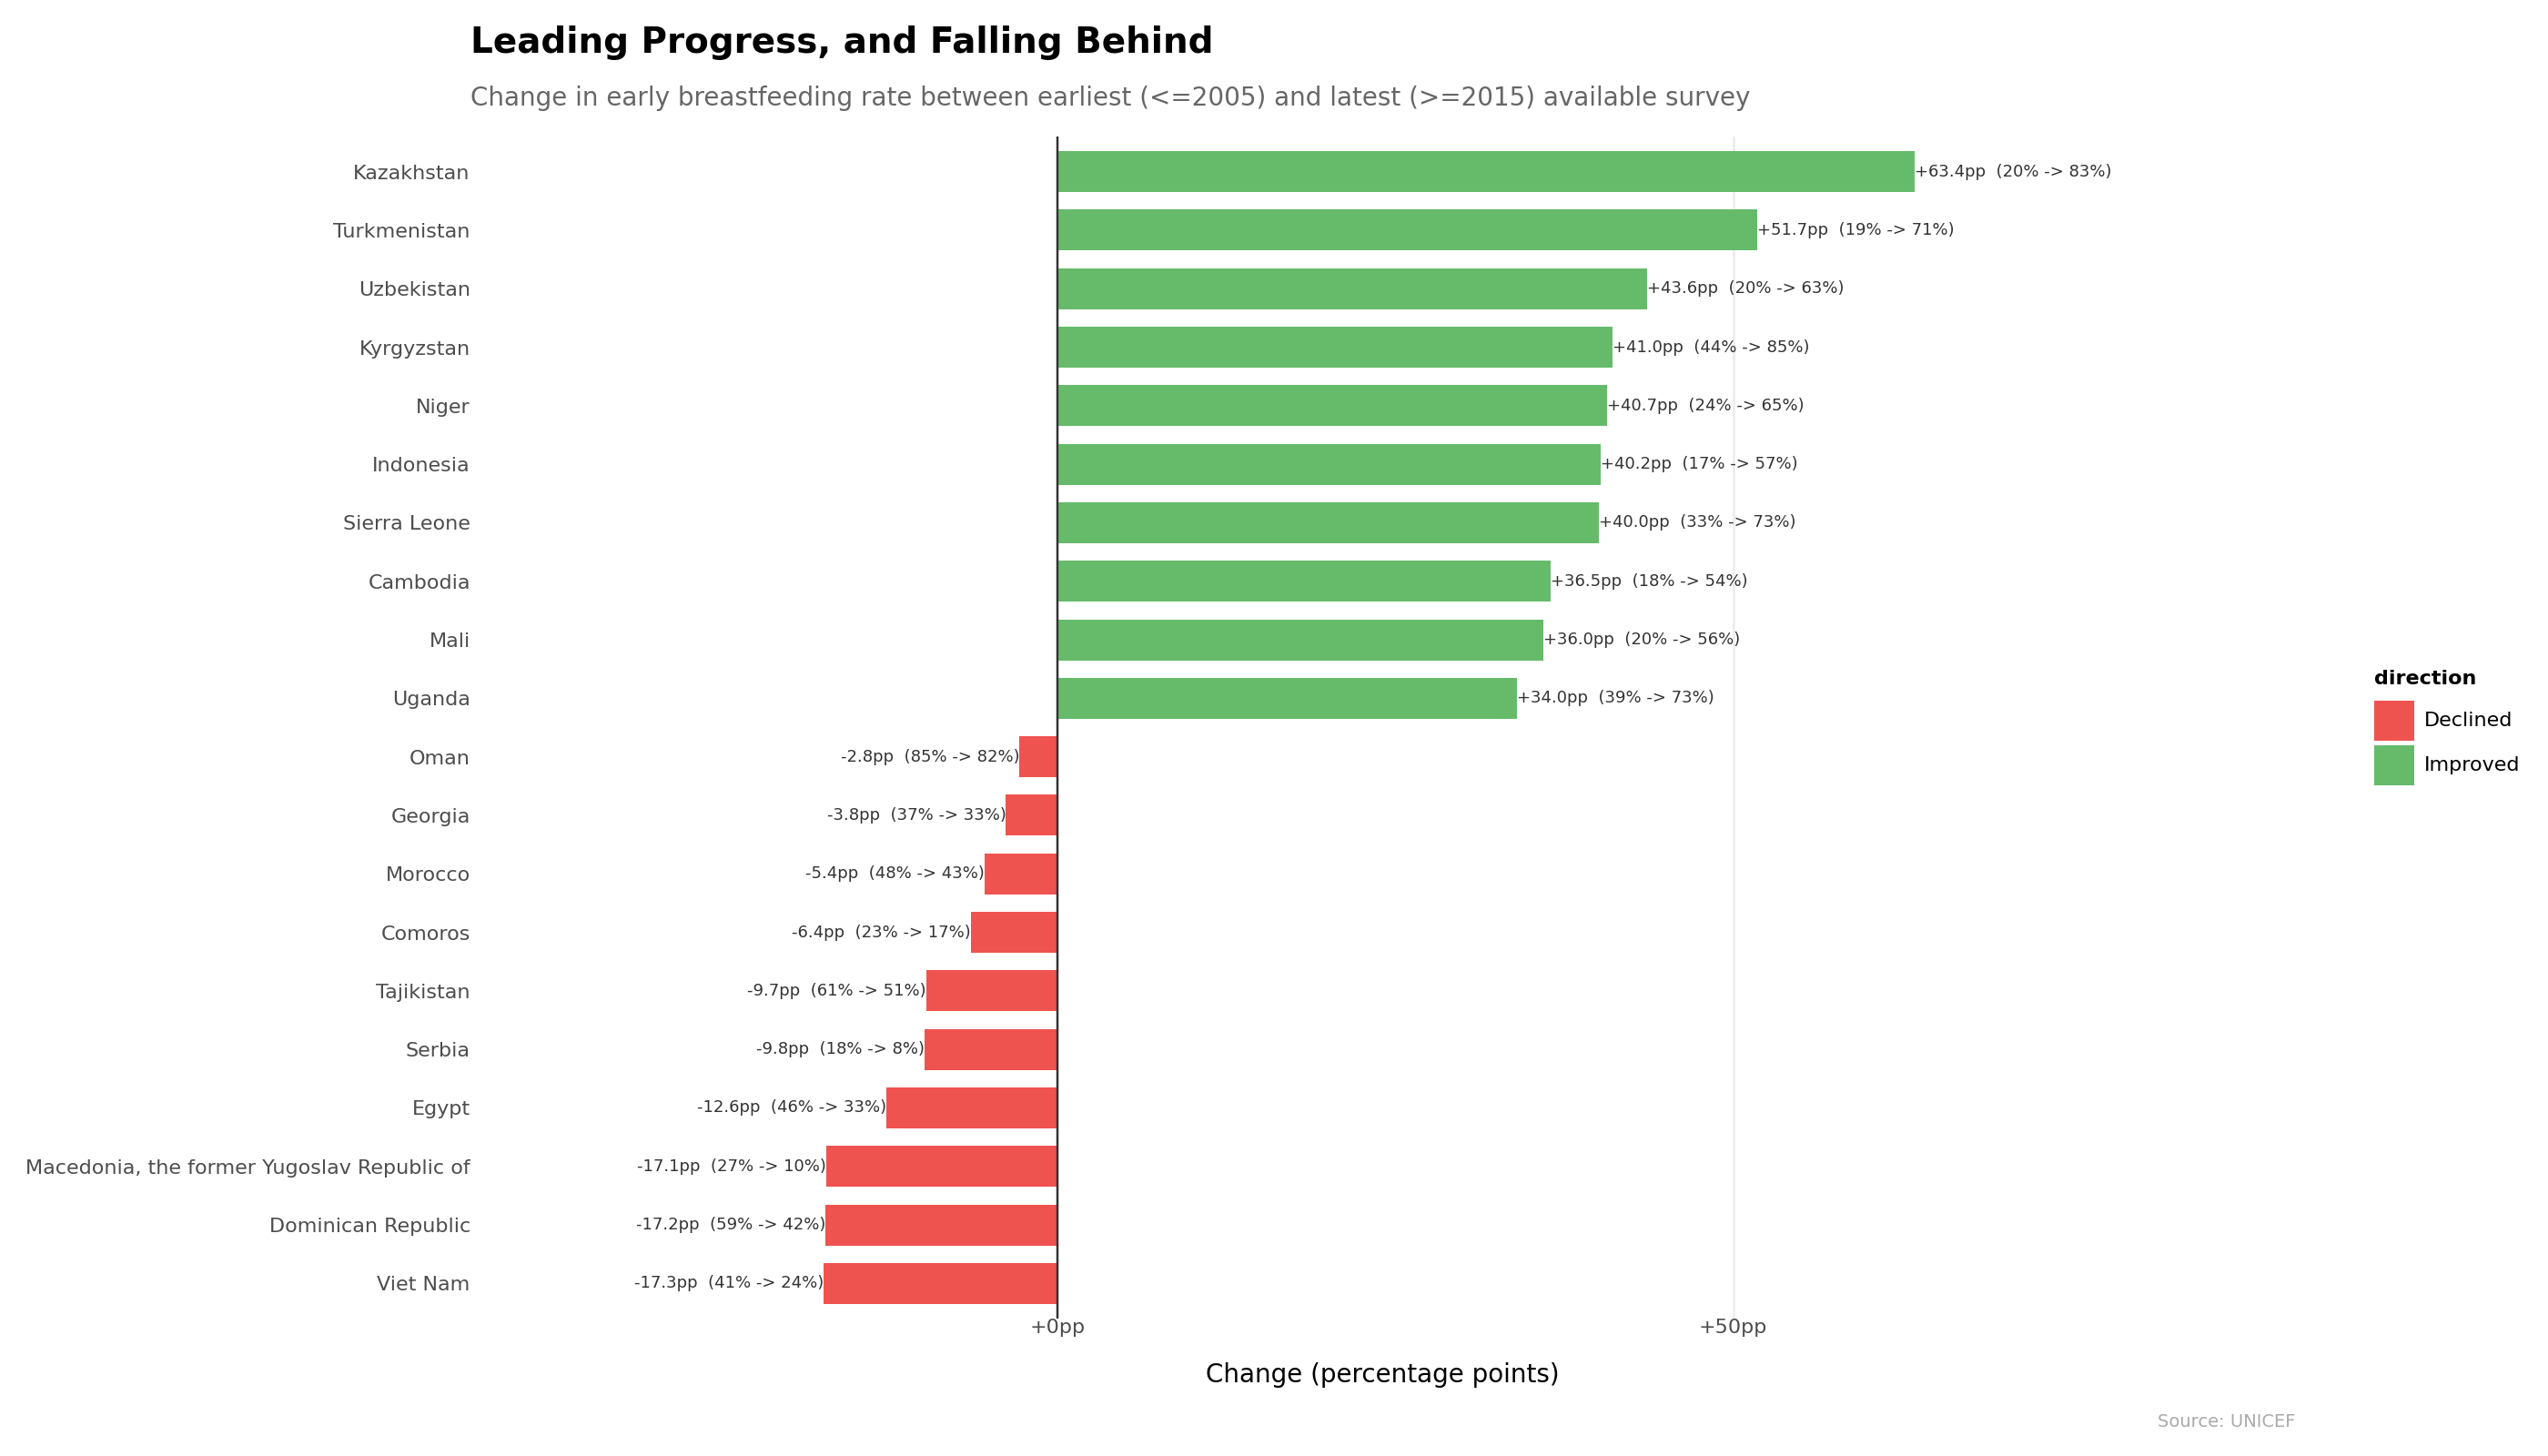

In [9]:
#| fig-cap: "Change in Early Breastfeeding Rates by Country"
#| fig-width: 13
#| fig-height: 8

ind2_early = (
    ind2_pl
    .filter((pl.col("sex") == "Total") & (pl.col("time_period") <= 2005))
    .group_by("country")
    .agg(pl.col("obs_value").mean().alias("early_val"))
)
ind2_late = (
    ind2_pl
    .filter((pl.col("sex") == "Total") & (pl.col("time_period") >= 2015))
    .group_by("country")
    .agg(pl.col("obs_value").mean().alias("late_val"))
)

change_bf = (
    ind2_early.join(ind2_late, on="country", how="inner")
    .drop_nulls()
    .with_columns(
        (pl.col("late_val") - pl.col("early_val")).alias("change")
    )
    .with_columns(
        (pl.col("change").map_elements(lambda x: f"{x:+.1f}pp", return_dtype=pl.Utf8)
         + "  (" + pl.col("early_val").round(0).cast(pl.Int64).cast(pl.Utf8) + "%"
         + " -> " + pl.col("late_val").round(0).cast(pl.Int64).cast(pl.Utf8) + "%)").alias("label")
    )
)

plot_bf = (
    pl.concat([
        change_bf.sort("change", descending=True).head(10),
        change_bf.sort("change").head(10),
    ])
    .sort("change")
    .with_columns([
        pl.when(pl.col("change") >= 0).then(pl.lit("Improved")).otherwise(pl.lit("Declined")).alias("direction"),
        pl.when(pl.col("change") >= 0).then(pl.lit(0.5)).otherwise(pl.lit(-0.5)).alias("nudge"),
        pl.when(pl.col("change") >= 0).then(pl.lit("left")).otherwise(pl.lit("right")).alias("h_just"),
    ])
)

# preserve sort order as ordered categorical for plotnine
countries_ordered = plot_bf["country"].to_list()
plot_bf = plot_bf.with_columns(
    pl.col("country").cast(pl.Enum(countries_ordered))
).to_pandas()

p2 = (
    ggplot(plot_bf, aes(x="country", y="change", fill="direction"))
    + geom_col(width=0.7, show_legend=True)
    + geom_hline(yintercept=0, color="#333333", size=0.5)
    + geom_text(aes(label="label", nudge_y="nudge", ha="h_just"),
                size=6.5, color="#333333")
    + scale_fill_manual(
        values={"Improved": "#66bb6a", "Declined": "#ef5350"},
        name=""
    )
    + scale_y_continuous(
        limits=[plot_bf["change"].min() - 20, plot_bf["change"].max() + 22],
        labels=lambda l: [f"{v:+.0f}pp" for v in l]
    )
    + coord_flip()
    + labs(
        title="Leading Progress, and Falling Behind",
        subtitle="Change in early breastfeeding rate between earliest (<=2005) and latest (>=2015) available survey",
        x="", y="Change (percentage points)",
        caption="Source: UNICEF",
    )
    + BASE_THEME
    + theme(
        panel_grid_major_y = element_blank(),
        figure_size        = (14, 8),
    )
)
p2

## Do development and healthcare factors influence breastfeeding rates?
Countries with higher skilled birth attendants generally tend to have higher breastfeeding rates, but the relationship is not consistent. Several countries with high percentage of skilled attendants still show moderate or low breastfeeding rates, indicating that **healthcare access and facilities alone does not guarantee early breastfeeding**. Cultural
norms, hospital practices, and policy interventions may play a much larger role.

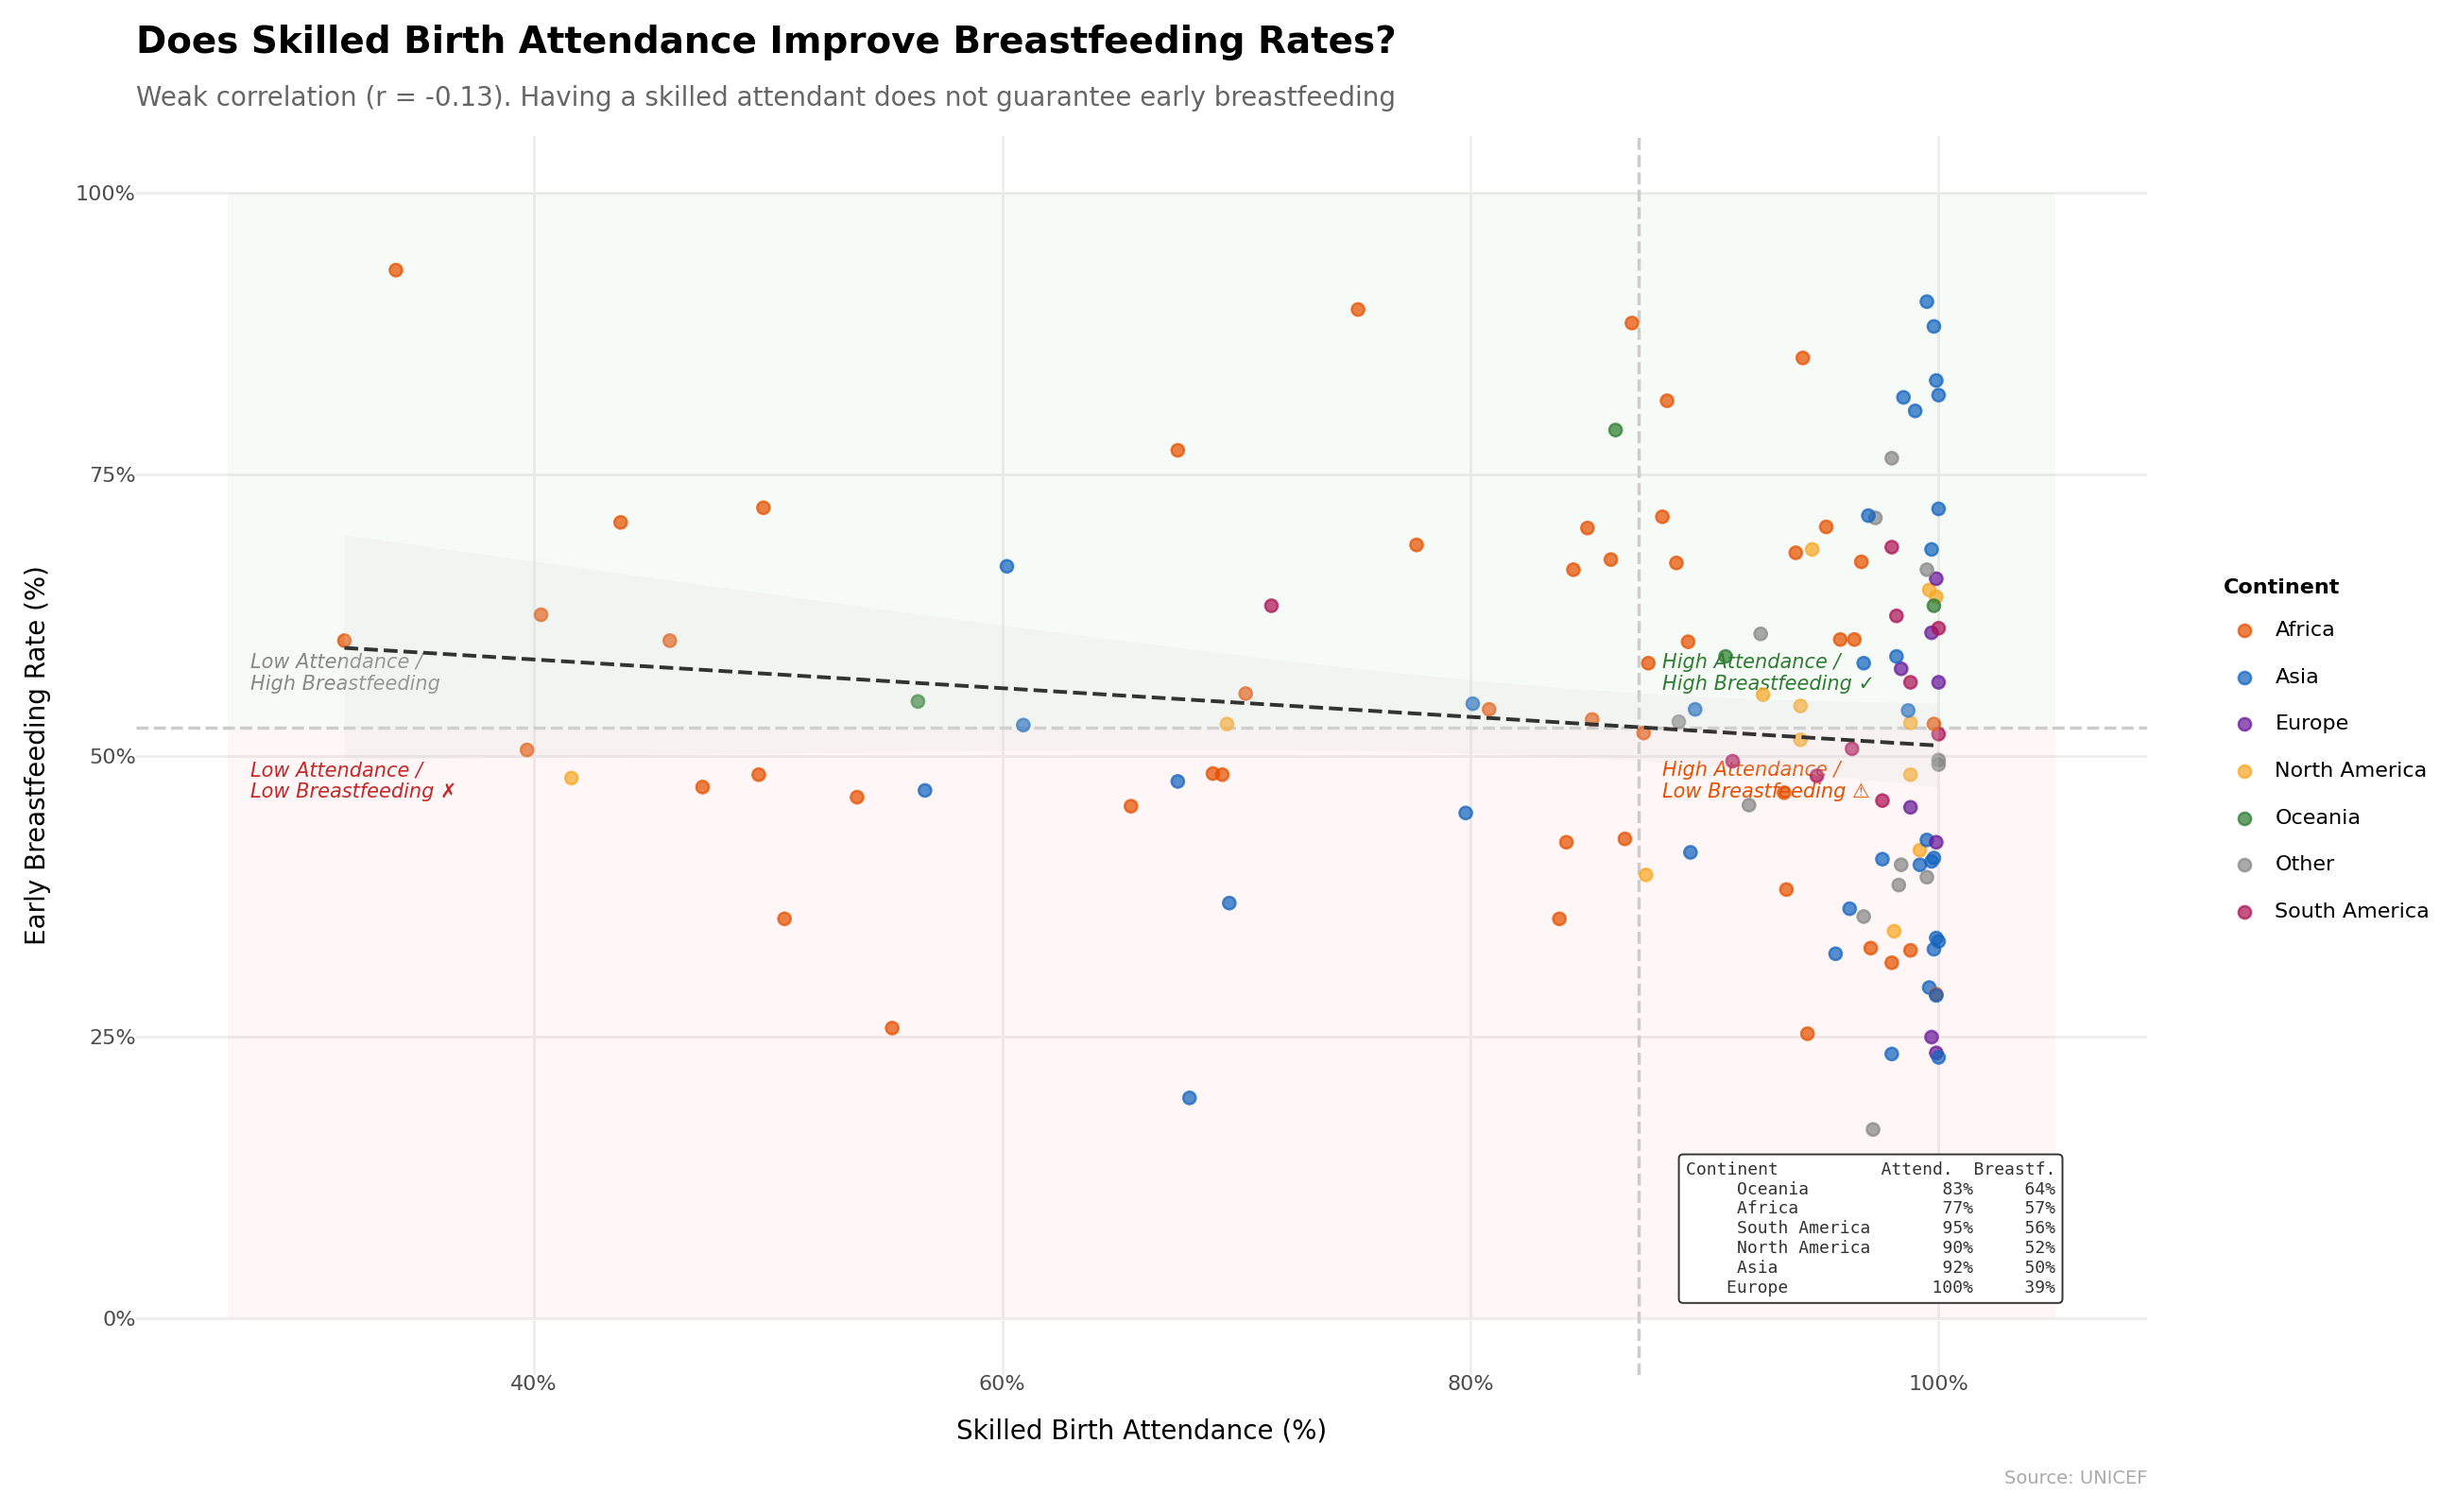

In [10]:
#| fig-cap: "Breastfeeding Rate vs Skilled Birth Attendance by Country"
#| fig-width: 13
#| fig-height: 8

df_scat = merged.dropna(subset=["skilled_birth_pct", "breastfeed_pct"]).copy()
df_scat = df_scat.merge(
    world[["alpha_3_code", "CONTINENT"]].drop_duplicates(),
    on="alpha_3_code", how="left"
)
df_scat["CONTINENT"] = df_scat["CONTINENT"].fillna("Other")
r_bf_sba = df_scat["skilled_birth_pct"].corr(df_scat["breastfeed_pct"])

sba_avg = df_scat["skilled_birth_pct"].mean()
bf_avg  = df_scat["breastfeed_pct"].mean()
x_min   = df_scat["skilled_birth_pct"].min() - 5

cont_scat = (
    df_scat[df_scat["CONTINENT"] != "Other"]
    .groupby("CONTINENT")[["skilled_birth_pct", "breastfeed_pct"]]
    .mean().round(0).astype(int).reset_index()
    .sort_values("breastfeed_pct", ascending=False)
    .rename(columns={"skilled_birth_pct": "att", "breastfeed_pct": "bf"})
)
table_lines = ["Continent          Attend.  Breastf."]
table_lines += [f"{r['CONTINENT']:<18}  {r['att']}%     {r['bf']}%"
                for _, r in cont_scat.iterrows()]
table_text = "\n".join(table_lines)

p4 = (
    ggplot(df_scat, aes(x="skilled_birth_pct", y="breastfeed_pct",
                        color="CONTINENT"))
    + annotate("rect", xmin=x_min, xmax=sba_avg,
               ymin=bf_avg, ymax=100, alpha=0.03, fill="green")
    + annotate("rect", xmin=sba_avg, xmax=105,
               ymin=bf_avg, ymax=100, alpha=0.03, fill="green")
    + annotate("rect", xmin=x_min, xmax=sba_avg,
               ymin=0, ymax=bf_avg, alpha=0.03, fill="red")
    + annotate("rect", xmin=sba_avg, xmax=105,
               ymin=0, ymax=bf_avg, alpha=0.03, fill="red")
    + geom_vline(xintercept=sba_avg, linetype="dashed",
                 color="#cccccc", size=0.7)
    + geom_hline(yintercept=bf_avg, linetype="dashed",
                 color="#cccccc", size=0.7)
    + annotate("text", x=x_min + 1, y=bf_avg + 3,
               label="Low Attendance /\nHigh Breastfeeding",
               size=FONT_ANNOT - 0.5, color="#888888", fontstyle="italic", ha="left", va="bottom")
    + annotate("text", x=sba_avg + 1, y=bf_avg + 3,
               label="High Attendance /\nHigh Breastfeeding ✓",
               size=FONT_ANNOT - 0.5, color=C_GREEN, fontstyle="italic", ha="left", va="bottom")
    + annotate("text", x=x_min + 1, y=bf_avg - 3,
               label="Low Attendance /\nLow Breastfeeding ✗",
               size=FONT_ANNOT - 0.5, color=C_RED, fontstyle="italic", ha="left", va="top")
    + annotate("text", x=sba_avg + 1, y=bf_avg - 3,
               label="High Attendance /\nLow Breastfeeding ⚠",
               size=FONT_ANNOT - 0.5, color=C_ORANGE, fontstyle="italic", ha="left", va="top")
    + geom_point(alpha=0.72, size=2.2)
    + geom_smooth(aes(group=1), method="lm", color="#333333",
                  linetype="dashed", fill="#dddddd", alpha=0.2, size=0.8)
    + annotate("label", x=105, y=2,
               label=table_text,
               size=6.5, ha="right", va="bottom",
               family="monospace",
               label_padding=0.4,
               fill="white", color="#333333")
    + scale_color_manual(values=CONT_COLORS, name="Continent")
    + scale_x_continuous(
        limits=[x_min, 105],
        labels=lambda l: [f"{int(v)}%" for v in l]
    )
    + scale_y_continuous(
        limits=[0, 100],
        labels=lambda l: [f"{int(v)}%" for v in l]
    )
    + labs(
        title="Does Skilled Birth Attendance Improve Breastfeeding Rates?",
        subtitle=f"Weak correlation (r = {r_bf_sba:.2f}). Having a skilled attendant does not guarantee early breastfeeding",
        x="Skilled Birth Attendance (%)",
        y="Early Breastfeeding Rate (%)",
        caption="Source: UNICEF",
    )
    + BASE_THEME
    + theme(figure_size=(13, 8))
)
p4

## How do other factors relate to early breastfeeding rates across countries?

### Breastfeeding vs Life Expectancy

Countries with higher life expectancy generally tend to have better breastfeeding rates, indicating an overall link between broader health outcomes and early child care practices. However, the relationship is not strong, suggesting other factors also play a role.

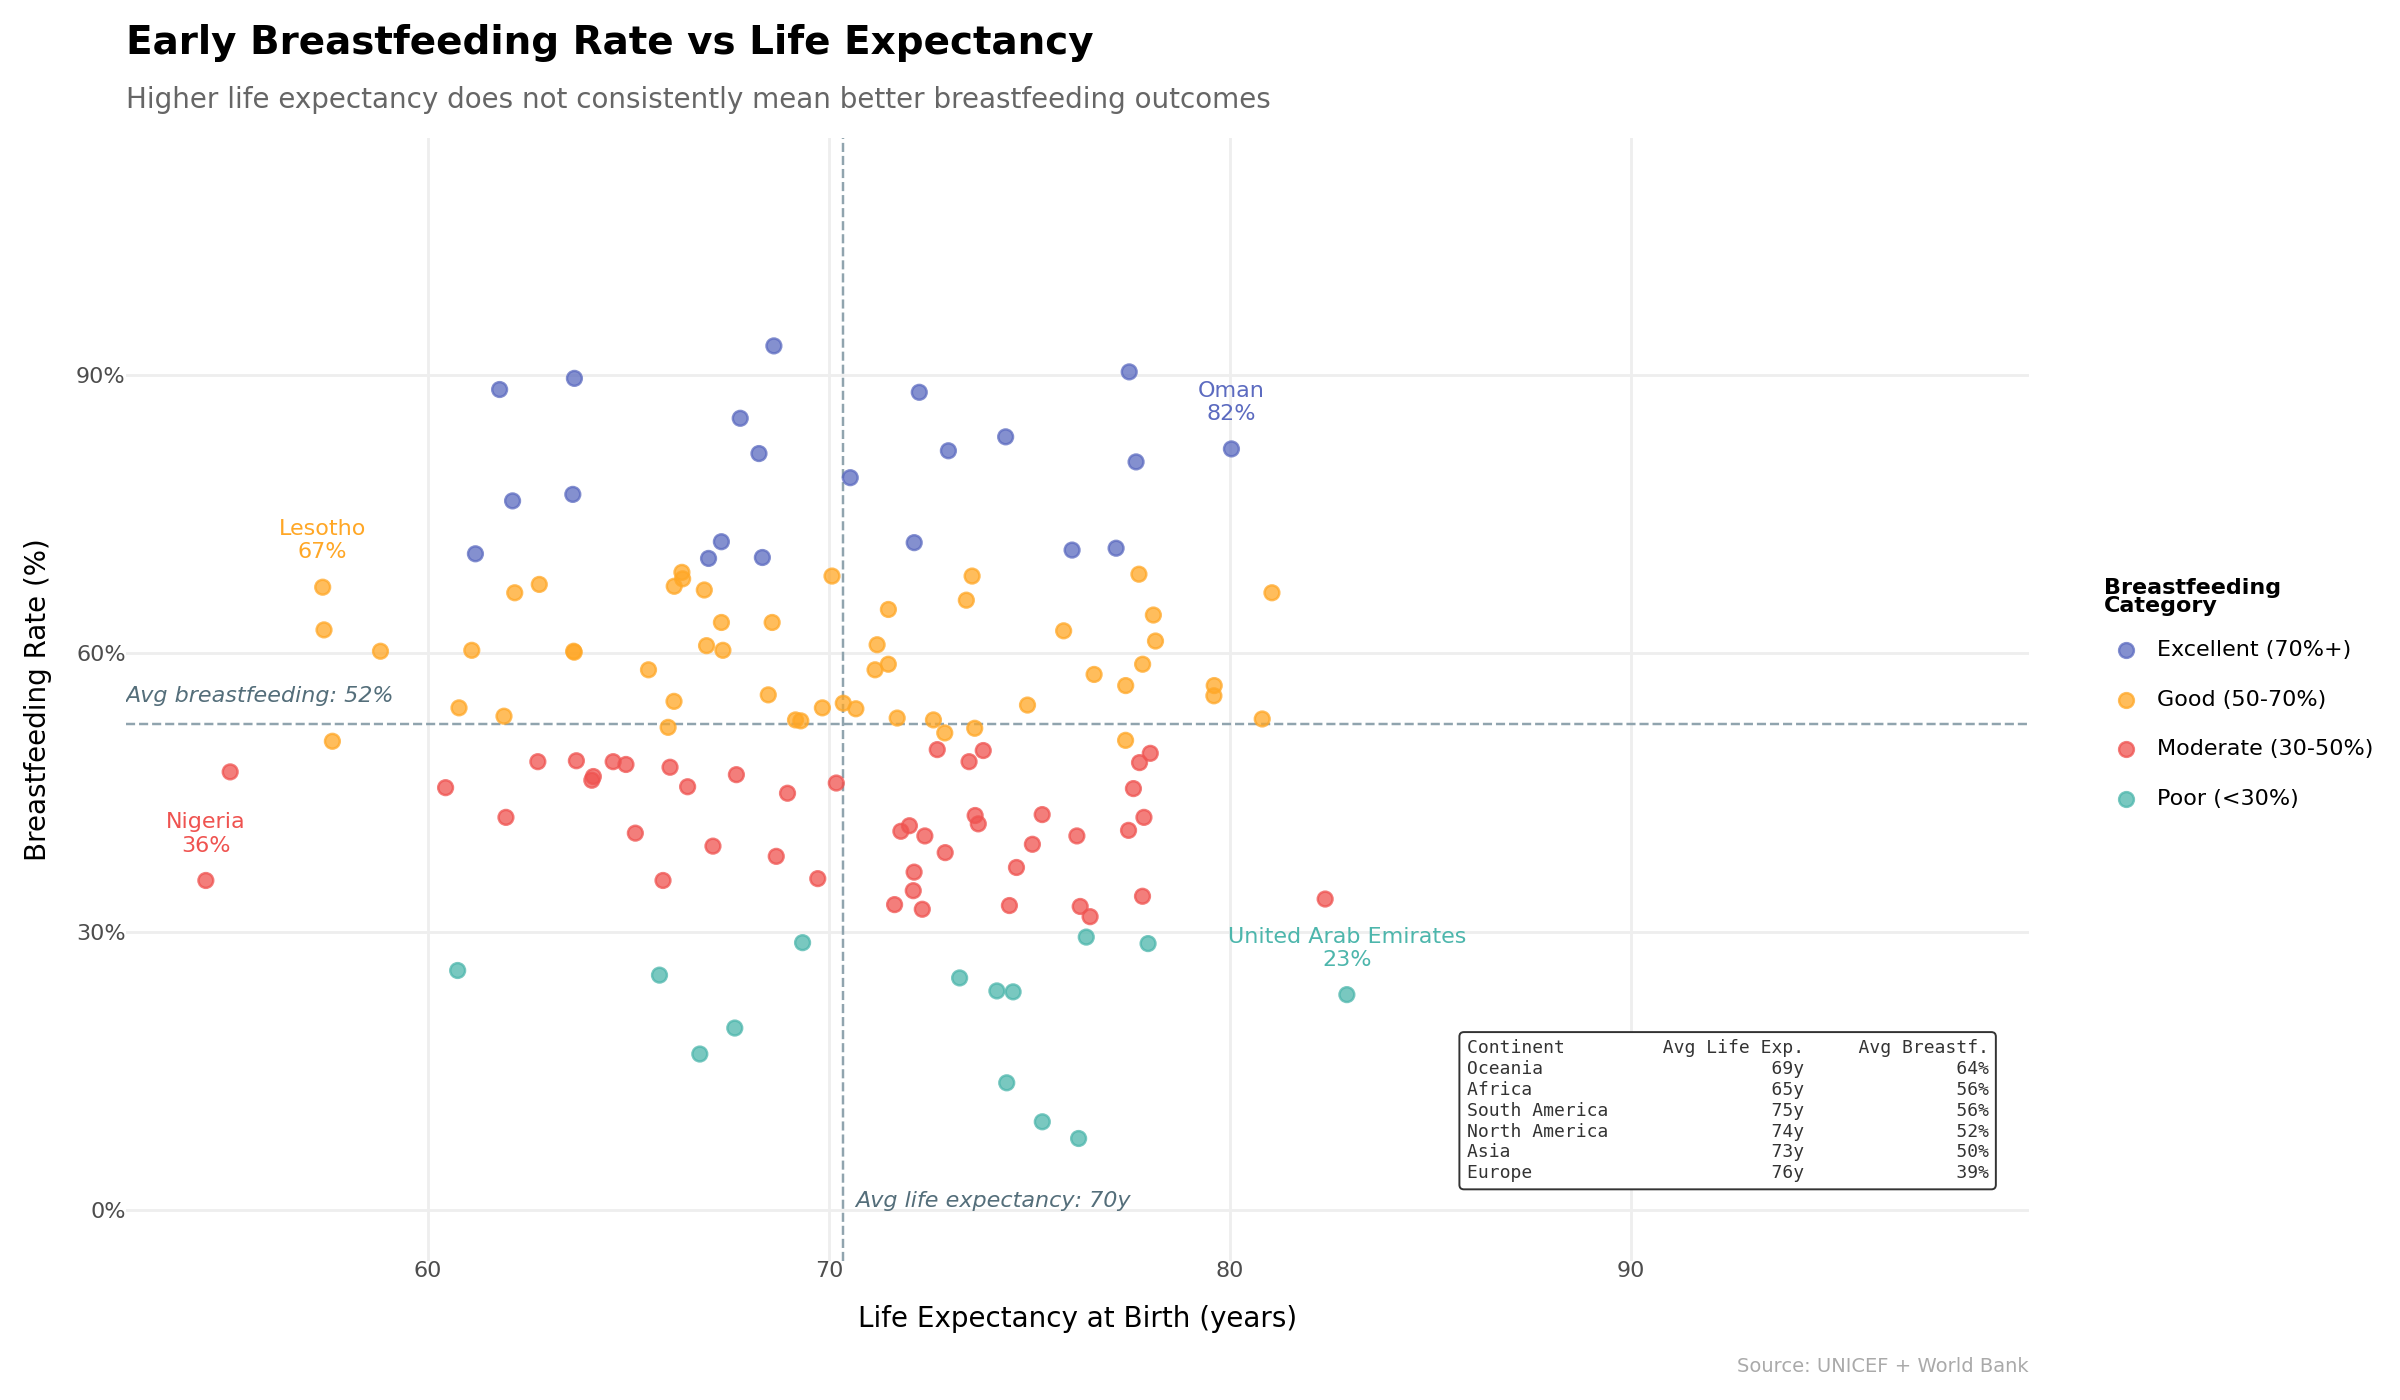

In [11]:
#| fig-cap: "Breastfeeding Rate vs Life Expectancy by Country"
#| fig-width: 13
#| fig-height: 8

df_le = (
    merged
    .dropna(subset=["breastfeed_pct", "life_expectancy"])
    .merge(world[["alpha_3_code", "CONTINENT"]].drop_duplicates(),
           on="alpha_3_code", how="left")
    .copy()
)
df_le["CONTINENT"] = df_le["CONTINENT"].fillna("Other")
df_le["category"] = np.select(
    [
        df_le["breastfeed_pct"] <= 30,
        df_le["breastfeed_pct"] <= 50,
        df_le["breastfeed_pct"] <= 70,
    ],
    ["Poor (<30%)", "Moderate (30-50%)", "Good (50-70%)"],
    default="Excellent (70%+)"
)

avg_bf = df_le["breastfeed_pct"].mean()
avg_le = df_le["life_expectancy"].mean()

CAT_COLORS = {
    "Poor (<30%)":       "#4db6ac",
    "Moderate (30-50%)": "#ef5350",
    "Good (50-70%)":     "#ffa726",
    "Excellent (70%+)":  "#5c6bc0",
}

outliers_le = (
    df_le.groupby("category", observed=True)
    .apply(lambda g: g.loc[(g["life_expectancy"] - avg_le).abs().idxmax()])
    .reset_index(drop=True)
)
outliers_le["label"] = (
    outliers_le["country"] + "\n"
    + outliers_le["breastfeed_pct"].round(0).astype(int).astype(str) + "%"
)

cont_le = (
    df_le[df_le["CONTINENT"] != "Other"]
    .groupby("CONTINENT")[["life_expectancy", "breastfeed_pct"]]
    .mean().round(1).reset_index()
    .sort_values("breastfeed_pct", ascending=False)
)
table_le  = f"{'Continent':<16}  {'Avg Life Exp.':>13}  {'Avg Breastf.':>15}\n"
table_le += "\n".join([
    f"{r['CONTINENT']:<16}  {r['life_expectancy']:>12.0f}y  {r['breastfeed_pct']:>14.0f}%"
    for _, r in cont_le.iterrows()
])

p5 = (
    ggplot(df_le, aes(x="life_expectancy", y="breastfeed_pct", color="category"))
    + geom_vline(xintercept=avg_le,  linetype="dashed", color="#90a4ae", size=0.5)
    + geom_hline(yintercept=avg_bf,  linetype="dashed", color="#90a4ae", size=0.5)
    + geom_point(alpha=0.75, size=2.5)
    + geom_text(
        data=outliers_le,
        mapping=aes(x="life_expectancy", y="breastfeed_pct",
                    label="label", color="category"),
        size=FONT_ANNOT, nudge_y=5, ha="center", show_legend=False
    )
    + annotate("text", x=-np.inf, y=avg_bf + 3,
               label=f"Avg breastfeeding: {avg_bf:.0f}%",
               size=FONT_ANNOT, color="#546e7a", ha="left", fontstyle="italic")
    + annotate("text", x=avg_le + 0.3, y=1,
               label=f"Avg life expectancy: {avg_le:.0f}y",
               size=FONT_ANNOT, color="#546e7a", ha="left", fontstyle="italic")
    + scale_x_continuous(
    limits=[df_le["life_expectancy"].min() - 2,
            df_le["life_expectancy"].max() + 17],
    expand=(0, 0)
    )
    + annotate("label",
        x=df_le["life_expectancy"].max() + 16,
        y=3,
        label=table_le,
        size=6.5, ha="right", va="bottom",
        family="monospace", label_padding=0.4,
        fill="white", color="#333333")
    + theme(
        figure_size=(12, 7),
        plot_margin_bottom=0.10,
    )
    + scale_color_manual(values=CAT_COLORS, name="Breastfeeding\nCategory")
    + scale_y_continuous(
        limits=[0, 110],
        labels=lambda l: [f"{int(v)}%" for v in l]
    )
    + labs(
        title="Early Breastfeeding Rate vs Life Expectancy",
        subtitle="Higher life expectancy does not consistently mean better breastfeeding outcomes",
        x="Life Expectancy at Birth (years)",
        y="Breastfeeding Rate (%)",
        caption="Source: UNICEF + World Bank",
    )
    + BASE_THEME
    + theme(figure_size=(12, 7))
)
p5

### Breastfeeding vs GDP per Capita

Higher income levels do not consistently translate into better breastfeeding rates. Countries with similar GDP levels show wide variation in outcomes, indicating that economic development alone does not determine breastfeeding practices.

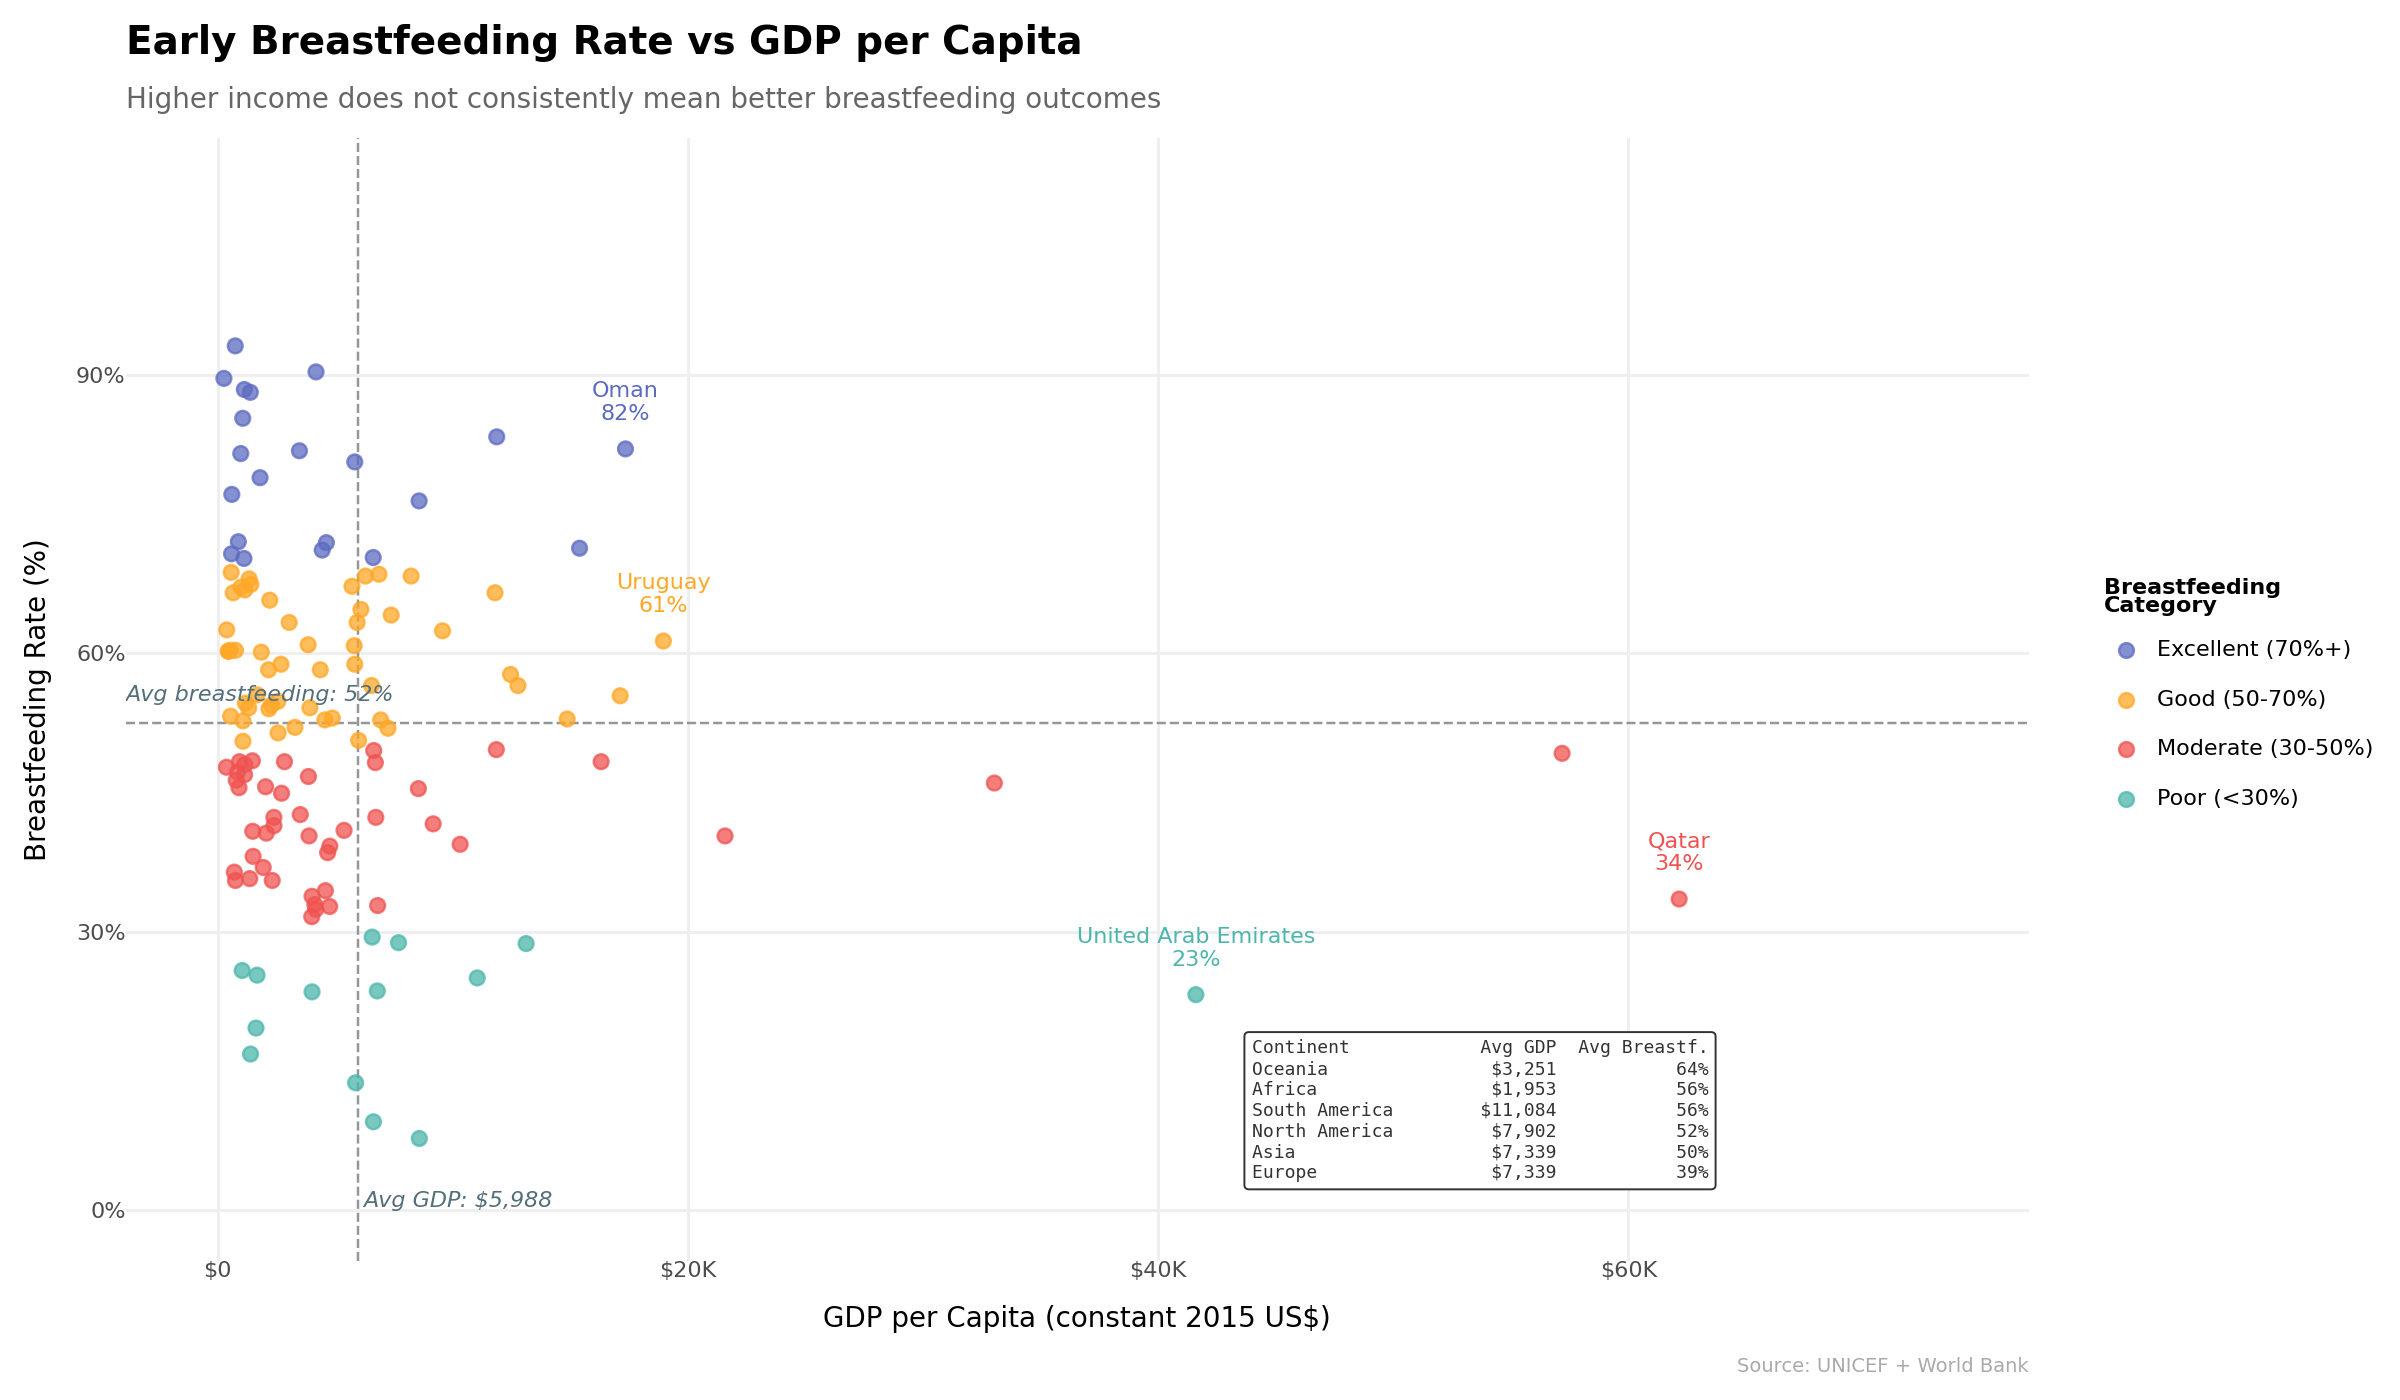

In [12]:
#| fig-cap: "Breastfeeding Rate vs GDP per Capita"
#| fig-width: 13
#| fig-height: 8
df_gdp = (
    merged
    .dropna(subset=["breastfeed_pct", "gdp_per_capita"])
    .merge(world[["alpha_3_code", "CONTINENT"]].drop_duplicates(),
           on="alpha_3_code", how="left")
    .copy()
)
df_gdp["CONTINENT"] = df_gdp["CONTINENT"].fillna("Other")
df_gdp["category"] = np.select(
    [
        df_gdp["breastfeed_pct"] <= 30,
        df_gdp["breastfeed_pct"] <= 50,
        df_gdp["breastfeed_pct"] <= 70,
    ],
    ["Poor (<30%)", "Moderate (30-50%)", "Good (50-70%)"],
    default="Excellent (70%+)"
)

avg_bf2 = df_gdp["breastfeed_pct"].mean()
avg_gdp = df_gdp["gdp_per_capita"].mean()

CAT_COLORS = {
    "Poor (<30%)":       "#4db6ac",
    "Moderate (30-50%)": "#ef5350",
    "Good (50-70%)":     "#ffa726",
    "Excellent (70%+)":  "#5c6bc0",
}

# One outlier per category, furthest from average GDP
outliers_gdp = (
    df_gdp.groupby("category", observed=True)
    .apply(lambda g: g.loc[(g["gdp_per_capita"] - avg_gdp).abs().idxmax()])
    .reset_index(drop=True)
)
outliers_gdp["label"] = (
    outliers_gdp["country"] + "\n"
    + outliers_gdp["breastfeed_pct"].round(0).astype(int).astype(str) + "%"
)

# Continent summary table
cont_gdp = (
    df_gdp[df_gdp["CONTINENT"] != "Other"]
    .groupby("CONTINENT")[["gdp_per_capita", "breastfeed_pct"]]
    .mean().round(0).reset_index()
    .sort_values("breastfeed_pct", ascending=False)
)
rows = []
for _, r in cont_gdp.iterrows():
    gdp_str = f"${r['gdp_per_capita']:,.0f}"       # e.g. "$3,251"
    bf_str  = f"{r['breastfeed_pct']:.0f}%"         # e.g. "64%"
    rows.append(f"{r['CONTINENT']:<16}  {gdp_str:>10}  {bf_str:>12}")

table_gdp  = f"{'Continent':<16}  {'Avg GDP':>10}  {'Avg Breastf.':>12}\n"
table_gdp += "\n".join(rows)

p6 = (
    ggplot(df_gdp, aes(x="gdp_per_capita", y="breastfeed_pct", color="category"))
    + geom_vline(xintercept=avg_gdp, linetype="dashed", color="#939799", size=0.5)
    + geom_hline(yintercept=avg_bf2, linetype="dashed", color="#939799", size=0.5)
    + geom_point(alpha=0.75, size=2.5)
    + geom_text(
        data=outliers_gdp,
        mapping=aes(x="gdp_per_capita", y="breastfeed_pct",
                    label="label", color="category"),
        size=FONT_ANNOT, nudge_y=5, ha="center", show_legend=False
    )
    + annotate("text", x=-np.inf, y=avg_bf2 + 3,
               label=f"Avg breastfeeding: {avg_bf2:.0f}%",
               size=FONT_ANNOT, color="#546e7a", ha="left", fontstyle="italic")
    + annotate("text", x=avg_gdp + 200, y=1,
               label=f"Avg GDP: ${avg_gdp:,.0f}",
               size=FONT_ANNOT, color="#546e7a", ha="left", fontstyle="italic")
    + annotate("label",
        x=df_gdp["gdp_per_capita"].max() * 1.02,   # just inside right limit
        y=3,                                          # just above y=0
        label=table_gdp,
        size=6.5, ha="right", va="bottom",
        family="monospace", label_padding=0.4,
        fill="white", color="#333333")
    + scale_x_continuous(
        limits=[df_gdp["gdp_per_capita"].min() - 500,
                df_gdp["gdp_per_capita"].max() * 1.18],  # extra right margin for table
        labels=lambda l: [f"${int(v/1000)}K" if v >= 1000 else f"${int(v)}" for v in l]
    )
    + scale_color_manual(values=CAT_COLORS, name="Breastfeeding\nCategory")
    + scale_y_continuous(
        limits=[0, 110],
        labels=lambda l: [f"{int(v)}%" for v in l]
    )
    + labs(
        title="Early Breastfeeding Rate vs GDP per Capita",
        subtitle="Higher income does not consistently mean better breastfeeding outcomes",
        x="GDP per Capita (constant 2015 US$)",
        y="Breastfeeding Rate (%)",
        caption="Source: UNICEF + World Bank",
    )
    + BASE_THEME
    + theme(figure_size=(12, 7))
)
p6

## A Critical Start, Still Unequal.

This analysis highlights that early initiation of breastfeeding remains uneven across the world, with significant disparities between countries and inconsistent progress over time. While some nations have improved, other countries have fallen behind, and in many cases, outdated data limits our understanding of current realities.

Importantly, no single economic or healthcare indicator fully explains these
differences. Instead, early breastfeeding practices appear to be shaped by a
complex interplay of factors:

- **Skilled birth attendance**: having a skilled attendant shows only a weak correlation with breastfeeding rates
- **Life expectancy**: higher life expectancy does not consistently lead to better breastfeeding outcomes
- **GDP per capita**: wealthier countries do not systematically outperform lower-income ones
- **Data gaps**: many countries lack recent survey data, limiting our understanding of current realities